Accelerometer calibration parameters were derived from six static axis-aligned orientations and evaluated on a separate tilted stationary capture. The corrected acceleration magnitude in the independent test had a mean of 0.9958 g and a standard deviation of 0.0020 g, corresponding to a mean magnitude error of approximately 0.42%.

Gyroscope bias was estimated from a stationary calibration capture and then applied to a separate stationary validation capture. The independent corrected means were approximately 0.0154 deg/s, 0.0104 deg/s, and −0.0145 deg/s for the X, Y, and Z rotation axes, respectively. The corrected standard deviations ranged from approximately 0.024 to 0.036 deg/s, closely matching the stationary noise observed during calibration.

In [185]:
# Imports
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [186]:
# Function to get middle 1000 readings
# These are likely more stable
def middle_window(data: pd.DataFrame, window_size: int = 1000) -> pd.DataFrame:
    if len(data) < window_size:
        raise ValueError(
            f"Capture has only {len(data)} samples; "
            f"cannot select {window_size}."
        )

    start = (len(data) - window_size) // 2
    return data.iloc[start:start + window_size].copy()

In [187]:
# Loading data
DATA_DIR = Path("/Users/tejparekh/Desktop/summer project/STM-IMU State Estimation/Python Analysis/Acceleration Calibration Data")

files = {
    "x-": DATA_DIR / "x-.csv",
    "x+": DATA_DIR / "x+.csv",
    "y-": DATA_DIR / "y-.csv",
    "y+": DATA_DIR / "y+.csv",
    "z-": DATA_DIR / "z-.csv",
    "z+": DATA_DIR / "z+.csv",
}

captures = {
    name: pd.read_csv(path)
    for name, path in files.items()
}

In [188]:
# Applying function
windows = {
    name: middle_window(data)
    for name, data in captures.items()
}

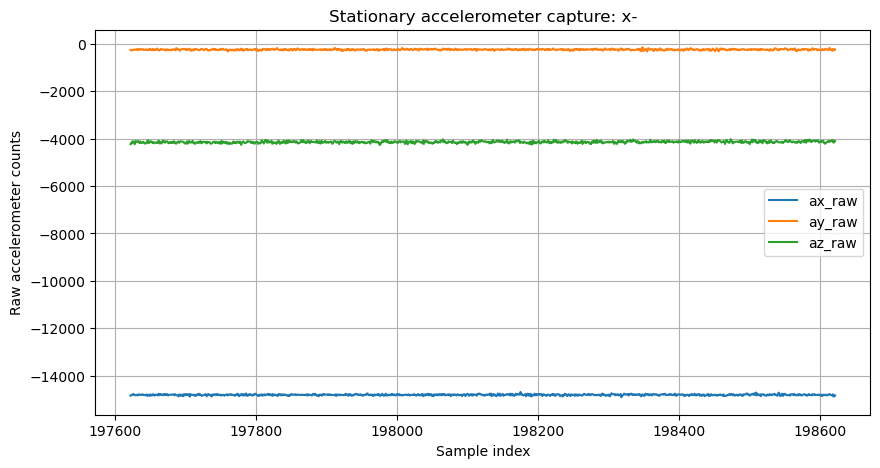

In [189]:
capture_name = "x-"
data = windows[capture_name]

plt.figure(figsize=(10, 5))

plt.plot(data["sample_index"], data["ax_raw"], label="ax_raw")
plt.plot(data["sample_index"], data["ay_raw"], label="ay_raw")
plt.plot(data["sample_index"], data["az_raw"], label="az_raw")

plt.title(f"Stationary accelerometer capture: {capture_name}")
plt.xlabel("Sample index")
plt.ylabel("Raw accelerometer counts")
plt.legend()
plt.grid(True)
plt.show()

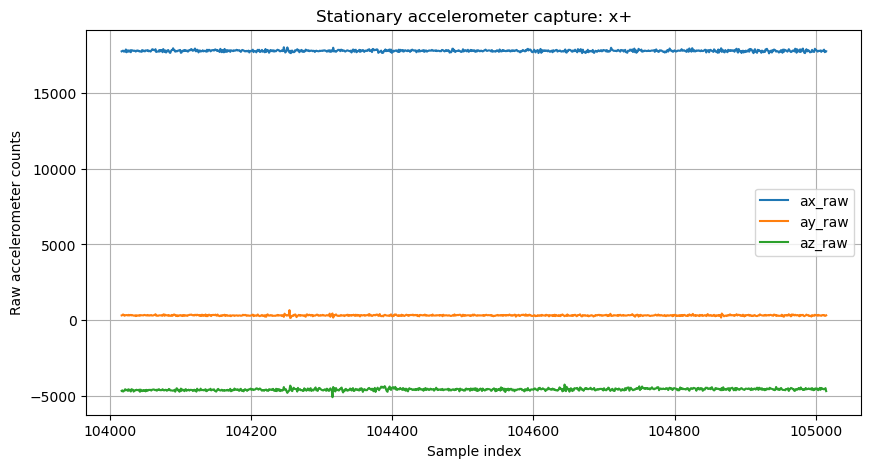

In [190]:
capture_name = "x+"
data = windows[capture_name]

plt.figure(figsize=(10, 5))

plt.plot(data["sample_index"], data["ax_raw"], label="ax_raw")
plt.plot(data["sample_index"], data["ay_raw"], label="ay_raw")
plt.plot(data["sample_index"], data["az_raw"], label="az_raw")

plt.title(f"Stationary accelerometer capture: {capture_name}")
plt.xlabel("Sample index")
plt.ylabel("Raw accelerometer counts")
plt.legend()
plt.grid(True)
plt.show()

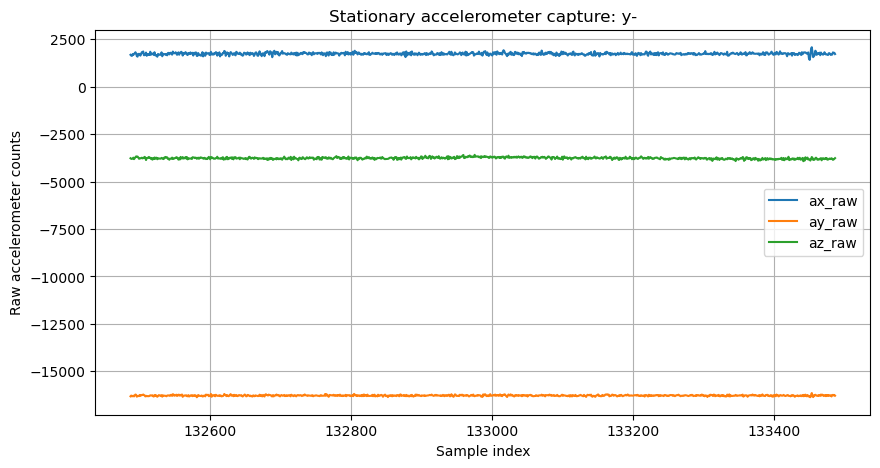

In [191]:
capture_name = "y-"
data = windows[capture_name]

plt.figure(figsize=(10, 5))

plt.plot(data["sample_index"], data["ax_raw"], label="ax_raw")
plt.plot(data["sample_index"], data["ay_raw"], label="ay_raw")
plt.plot(data["sample_index"], data["az_raw"], label="az_raw")

plt.title(f"Stationary accelerometer capture: {capture_name}")
plt.xlabel("Sample index")
plt.ylabel("Raw accelerometer counts")
plt.legend()
plt.grid(True)
plt.show()

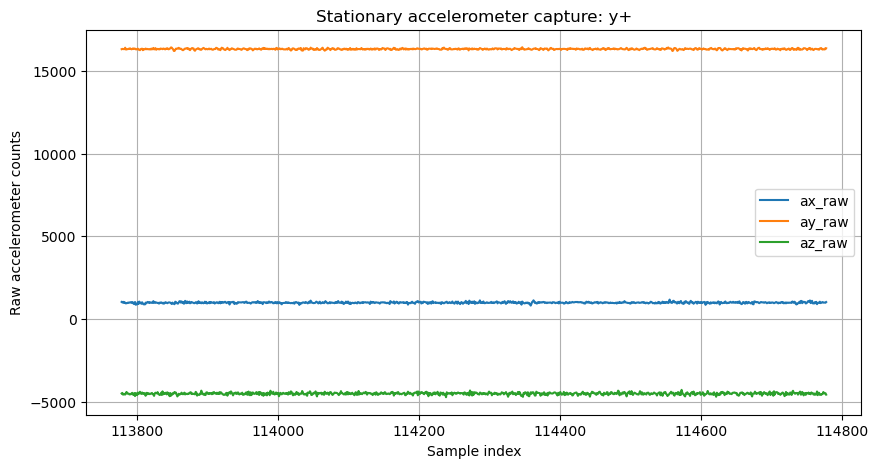

In [192]:
capture_name = "y+"
data = windows[capture_name]

plt.figure(figsize=(10, 5))

plt.plot(data["sample_index"], data["ax_raw"], label="ax_raw")
plt.plot(data["sample_index"], data["ay_raw"], label="ay_raw")
plt.plot(data["sample_index"], data["az_raw"], label="az_raw")

plt.title(f"Stationary accelerometer capture: {capture_name}")
plt.xlabel("Sample index")
plt.ylabel("Raw accelerometer counts")
plt.legend()
plt.grid(True)
plt.show()

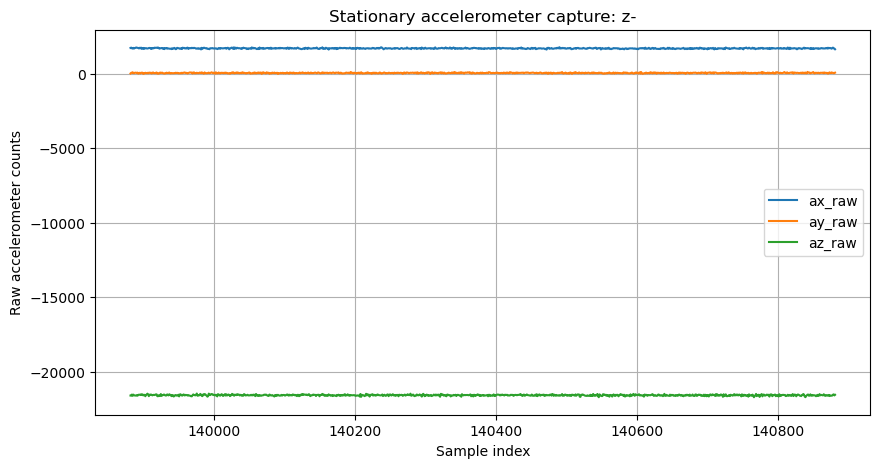

In [193]:
capture_name = "z-"
data = windows[capture_name]

plt.figure(figsize=(10, 5))

plt.plot(data["sample_index"], data["ax_raw"], label="ax_raw")
plt.plot(data["sample_index"], data["ay_raw"], label="ay_raw")
plt.plot(data["sample_index"], data["az_raw"], label="az_raw")

plt.title(f"Stationary accelerometer capture: {capture_name}")
plt.xlabel("Sample index")
plt.ylabel("Raw accelerometer counts")
plt.legend()
plt.grid(True)
plt.show()

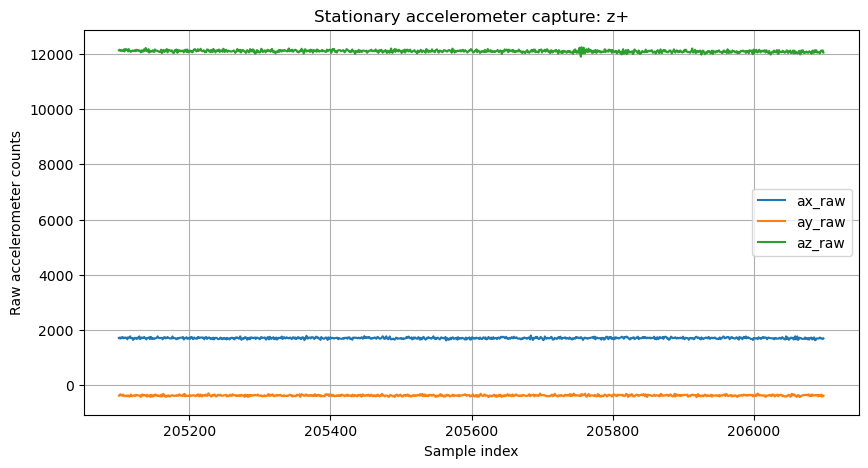

In [194]:
capture_name = "z+"
data = windows[capture_name]

plt.figure(figsize=(10, 5))

plt.plot(data["sample_index"], data["ax_raw"], label="ax_raw")
plt.plot(data["sample_index"], data["ay_raw"], label="ay_raw")
plt.plot(data["sample_index"], data["az_raw"], label="az_raw")

plt.title(f"Stationary accelerometer capture: {capture_name}")
plt.xlabel("Sample index")
plt.ylabel("Raw accelerometer counts")
plt.legend()
plt.grid(True)
plt.show()

In [195]:
# Calculating un-adjusted reading statistics
rows = []

for orientation, data in windows.items():
    rows.append({
        "orientation": orientation,
        "ax_mean": data["ax_raw"].mean(),
        "ay_mean": data["ay_raw"].mean(),
        "az_mean": data["az_raw"].mean(),
        "ax_std": data["ax_raw"].std(),
        "ay_std": data["ay_raw"].std(),
        "az_std": data["az_raw"].std(),
    })

summary = pd.DataFrame(rows).set_index("orientation")
summary

,ax_mean,ay_mean,az_mean,ax_std,ay_std,az_std
orientation,,,,,,
x-,-14809.496,-247.838,-4145.390,25.928407,23.512265,40.097777
x+,17807.588,309.542,-4587.844,58.845331,34.186942,68.224734
y-,1741.122,-16279.066,-3763.916,60.293253,28.622909,49.059635
y+,988.162,16325.640,-4510.914,40.539033,34.677383,64.926667
z-,1702.060,52.672,-21584.600,25.706210,22.379125,39.495923
z+,1707.632,-368.810,12094.908,27.120917,23.861879,40.767604


In [196]:
# Bias and sensitivity calculations
axis_columns = {
    "x": "ax_raw",
    "y": "ay_raw",
    "z": "az_raw",
}

calibration_rows = []

for axis, column in axis_columns.items():
    positive_mean = windows[f"{axis}+"][column].mean()
    negative_mean = windows[f"{axis}-"][column].mean()

    bias = (positive_mean + negative_mean) / 2.0
    sensitivity = (positive_mean - negative_mean) / 2.0

    calibration_rows.append({
        "axis": axis,
        "positive_mean": positive_mean,
        "negative_mean": negative_mean,
        "bias_counts": bias,
        "sensitivity_counts_per_g": sensitivity,
        "sensitivity_error_percent":
            100.0 * (sensitivity - 16384.0) / 16384.0,
    })

calibration = pd.DataFrame(calibration_rows).set_index("axis")
calibration

,positive_mean,negative_mean,bias_counts,sensitivity_counts_per_g,sensitivity_error_percent
axis,,,,,
x,17807.588,-14809.496,1499.046,16308.542,-0.460559
y,16325.640,-16279.066,23.287,16302.353,-0.498334
z,12094.908,-21584.600,-4744.846,16839.754,2.781702


In [197]:
# Bias adjustment
calibration_params = calibration.to_dict(orient="index")

corrected = {}

for orientation, data in windows.items():
    corrected_data = data.copy()

    for axis, column in axis_columns.items():
        bias = calibration_params[axis]["bias_counts"]
        sensitivity = calibration_params[axis]["sensitivity_counts_per_g"]

        corrected_data[f"a{axis}_g_corrected"] = (
            corrected_data[column] - bias
        ) / sensitivity

    corrected_data["magnitude_g"] = np.sqrt(
        corrected_data["ax_g_corrected"] ** 2
        + corrected_data["ay_g_corrected"] ** 2
        + corrected_data["az_g_corrected"] ** 2
    )

    corrected[orientation] = corrected_data

In [198]:
# Adjusted magnitude statistics
validation_rows = []

for orientation, data in corrected.items():
    validation_rows.append({
        "orientation": orientation,
        "mean_magnitude_g": data["magnitude_g"].mean(),
        "std_magnitude_g": data["magnitude_g"].std(),
        "min_magnitude_g": data["magnitude_g"].min(),
        "max_magnitude_g": data["magnitude_g"].max(),
    })

validation = pd.DataFrame(validation_rows).set_index("orientation")
validation

,mean_magnitude_g,std_magnitude_g,min_magnitude_g,max_magnitude_g
orientation,,,,
x-,1.000775,0.001590,0.993253,1.006998
x+,1.000208,0.003614,0.989795,1.014855
y-,1.001816,0.001732,0.994536,1.007064
y+,1.000598,0.002100,0.993306,1.007046
z-,1.000081,0.002345,0.993389,1.008143
z+,1.000373,0.002418,0.988655,1.009025


In [199]:
# Data comes from random steady orientation
tilted = pd.read_csv(DATA_DIR / "tilted_test.csv")

In [200]:
# Get middle 1000 samples
tilted_window = middle_window(tilted, window_size=1000)

In [201]:
# Apply bias adjustment
tilted_corrected = tilted_window.copy()

for axis, column in axis_columns.items():
    bias = calibration_params[axis]["bias_counts"]
    sensitivity = calibration_params[axis]["sensitivity_counts_per_g"]

    tilted_corrected[f"a{axis}_g_corrected"] = (
        tilted_corrected[column] - bias
    ) / sensitivity

In [202]:
# Adjusted magnitude calculation
tilted_corrected["magnitude_g"] = np.sqrt(
    tilted_corrected["ax_g_corrected"] ** 2
    + tilted_corrected["ay_g_corrected"] ** 2
    + tilted_corrected["az_g_corrected"] ** 2
)

print("Corrected axis means:")
print(
    tilted_corrected[
        [
            "ax_g_corrected",
            "ay_g_corrected",
            "az_g_corrected",
        ]
    ].mean()
)

print("\nCorrected acceleration magnitude:")
print(tilted_corrected["magnitude_g"].describe())

Corrected axis means:
ax_g_corrected    0.564295
ay_g_corrected    0.458544
az_g_corrected    0.680343
dtype: float64

Corrected acceleration magnitude:
count    1000.000000
mean        0.995773
std         0.002030
min         0.988164
25%         0.994437
50%         0.995804
75%         0.997184
max         1.001259
Name: magnitude_g, dtype: float64


In [203]:
DATA_DIR = Path("Gyro Calibration Data")
gyro = pd.read_csv(DATA_DIR / "imu_stationary_full.csv")

In [204]:
gyro_window = middle_window(gyro, window_size=3000)

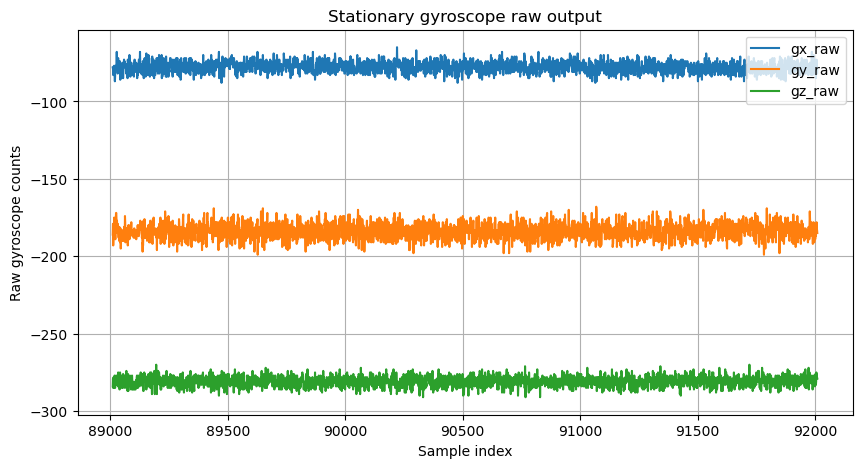

In [205]:
plt.figure(figsize=(10, 5))

plt.plot(
    gyro_window["sample_index"],
    gyro_window["gx_raw"],
    label="gx_raw",
)

plt.plot(
    gyro_window["sample_index"],
    gyro_window["gy_raw"],
    label="gy_raw",
)

plt.plot(
    gyro_window["sample_index"],
    gyro_window["gz_raw"],
    label="gz_raw",
)

plt.title("Stationary gyroscope raw output")
plt.xlabel("Sample index")
plt.ylabel("Raw gyroscope counts")
plt.legend()
plt.grid(True)
plt.show()

In [206]:
gyro_raw_columns = [
    "gx_raw",
    "gy_raw",
    "gz_raw",
]

gyro_summary = pd.DataFrame({
    "mean_raw": gyro_window[gyro_raw_columns].mean(),
    "std_raw": gyro_window[gyro_raw_columns].std(),
    "min_raw": gyro_window[gyro_raw_columns].min(),
    "max_raw": gyro_window[gyro_raw_columns].max(),
})

gyro_summary

,mean_raw,std_raw,min_raw,max_raw
gx_raw,-77.802667,3.378490,-88,-65
gy_raw,-183.821333,4.838720,-199,-168
gz_raw,-280.871667,3.203948,-291,-270


In [207]:
GYRO_SENSITIVITY = 131.0

gyro_bias_raw = gyro_window[gyro_raw_columns].mean()

gyro_bias_dps = gyro_bias_raw / GYRO_SENSITIVITY

gyro_calibration = pd.DataFrame({
    "bias_raw_counts": gyro_bias_raw,
    "bias_dps": gyro_bias_dps,
})

gyro_calibration

,bias_raw_counts,bias_dps
gx_raw,-77.802667,-0.593913
gy_raw,-183.821333,-1.403216
gz_raw,-280.871667,-2.144059


In [208]:
gyro_corrected = gyro_window.copy()

axis_columns = {
    "x": "gx_raw",
    "y": "gy_raw",
    "z": "gz_raw",
}

for axis, column in axis_columns.items():
    bias = gyro_bias_raw[column]

    gyro_corrected[f"g{axis}_corrected_dps"] = (
        gyro_corrected[column] - bias
    ) / GYRO_SENSITIVITY

In [209]:
corrected_gyro_columns = [
    "gx_corrected_dps",
    "gy_corrected_dps",
    "gz_corrected_dps",
]

gyro_validation = gyro_corrected[
    corrected_gyro_columns
].agg(["mean", "std", "min", "max"])

gyro_validation

,gx_corrected_dps,gy_corrected_dps,gz_corrected_dps
mean,3.848773e-18,6.935193e-17,2.309264e-17
std,2.579000e-02,3.693680e-02,2.445762e-02
min,-7.784224e-02,-1.158677e-01,-7.731552e-02
max,9.773028e-02,1.207735e-01,8.298982e-02


In [210]:
gyro_test = pd.read_csv(
    DATA_DIR / "gyro_calibration_test.csv"
)

gyro_test_window = middle_window(
    gyro_test,
    window_size=3000,
)

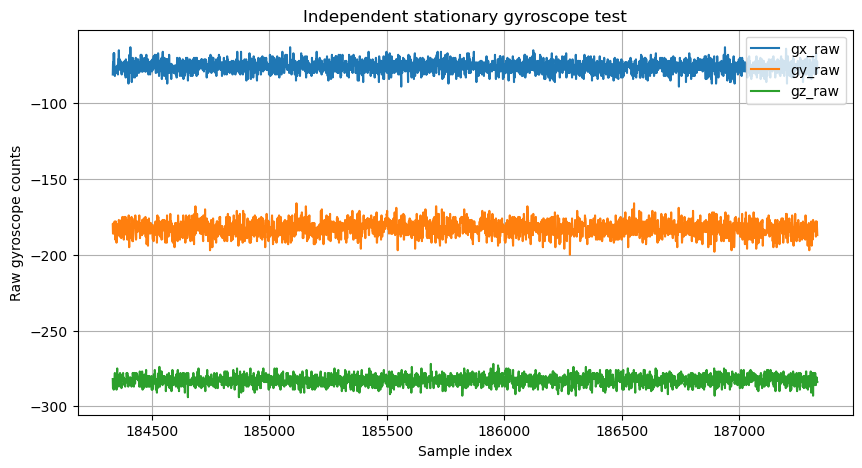

In [211]:
plt.figure(figsize=(10, 5))

plt.plot(
    gyro_test_window["sample_index"],
    gyro_test_window["gx_raw"],
    label="gx_raw",
)

plt.plot(
    gyro_test_window["sample_index"],
    gyro_test_window["gy_raw"],
    label="gy_raw",
)

plt.plot(
    gyro_test_window["sample_index"],
    gyro_test_window["gz_raw"],
    label="gz_raw",
)

plt.title("Independent stationary gyroscope test")
plt.xlabel("Sample index")
plt.ylabel("Raw gyroscope counts")
plt.legend()
plt.grid(True)
plt.show()

In [212]:
gyro_test_corrected = gyro_test_window.copy()

gyro_test_corrected["gx_corrected_dps"] = (
    gyro_test_corrected["gx_raw"]
    - gyro_bias_raw["gx_raw"]
) / GYRO_SENSITIVITY

gyro_test_corrected["gy_corrected_dps"] = (
    gyro_test_corrected["gy_raw"]
    - gyro_bias_raw["gy_raw"]
) / GYRO_SENSITIVITY

gyro_test_corrected["gz_corrected_dps"] = (
    gyro_test_corrected["gz_raw"]
    - gyro_bias_raw["gz_raw"]
) / GYRO_SENSITIVITY

In [213]:
gyro_test_columns = [
    "gx_corrected_dps",
    "gy_corrected_dps",
    "gz_corrected_dps",
]

gyro_test_validation = gyro_test_corrected[
    gyro_test_columns
].agg(["mean", "std", "min", "max"])

gyro_test_validation

,gx_corrected_dps,gy_corrected_dps,gz_corrected_dps
mean,0.015405,0.010407,-0.014466
std,0.028993,0.036170,0.024339
min,-0.085476,-0.123501,-0.100216
max,0.112997,0.136041,0.067723


In [214]:
# Combined IMU calibration parameters

imu_calibration_matrix = np.array([
    [
        calibration.loc["x", "bias_counts"],
        calibration.loc["y", "bias_counts"],
        calibration.loc["z", "bias_counts"],
    ],
    [
        calibration.loc["x", "sensitivity_counts_per_g"],
        calibration.loc["y", "sensitivity_counts_per_g"],
        calibration.loc["z", "sensitivity_counts_per_g"],
    ],
    [
        gyro_bias_raw["gx_raw"],
        gyro_bias_raw["gy_raw"],
        gyro_bias_raw["gz_raw"],
    ],
    [
        GYRO_SENSITIVITY,
        GYRO_SENSITIVITY,
        GYRO_SENSITIVITY,
    ],
])

imu_calibration = pd.DataFrame(
    imu_calibration_matrix,
    index=[
        "accel_bias_counts",
        "accel_sensitivity_counts_per_g",
        "gyro_bias_counts",
        "gyro_sensitivity_counts_per_dps",
    ],
    columns=["x", "y", "z"],
)

imu_calibration

,x,y,z
accel_bias_counts,1499.046000,23.287000,-4744.846000
accel_sensitivity_counts_per_g,16308.542000,16302.353000,16839.754000
gyro_bias_counts,-77.802667,-183.821333,-280.871667
gyro_sensitivity_counts_per_dps,131.000000,131.000000,131.000000
